I've always admired the ornate edges of the facades in my neighborhood (Ridgewood, Queens), and am always struck when I see them at golden hour. I want to create a map that shows which buildings have these cornices and represent these data through different techniques we discussed in class. I found a report from the NYC Landmarks Preservation Commission that describes historic buildings in Ridgewood in detail and provides year built. I took note of the year built with buildings that had cornices in the description, and filtered the Pluto dataset by the Ridgewood zip code and by these years built as an approximation for buildings that will probably have this architectural detail. 
I then performed a spatial join with a geojson I created to establish the area of the neighborhood itself, using the New York Times' neighborhood map as a reference. 
In this file I explore a few different iterations of mapping buildings with cornices in Ridgewood, trying to take into account how these buildings are perceived from the human / street view. I also created a web map* (through Liveserver and html1 in this folder), some more aestheticized representations in Photoshop (ridgewood2.png), and experimented with networks through the neighborhood that prioritized blocks with these buildings. This page also concludes with a little historical context on the distribution of buildings over years built for the main data set I'm exploring in contrast with distribution of buildings across years built for the rest of the buildings in the neighborhood. 

*After our discussion in class I wanted to challenge myself to get my webmap to better reflect my experience of beauty. I decided to update my Maputnik design to better reflect the color scheme of the buildings at sunset. It's not perfect, but it's closer!

In [3]:
import matplotlib.pyplot as plt  # for plotting
import geopandas as gpd  # for geospatial data handling
from matplotlib.lines import Line2D

# more advanced
from lonboard._map import Map
from lonboard._layer import PolygonLayer  # for mapping in 3D
from lonboard.colormap import (
    apply_categorical_cmap,
    apply_continuous_cmap,
)  # for assigning colors
from palettable.colorbrewer.sequential import PuRd_9  # for color palettes
from matplotlib.colors import LogNorm  # for logarithmic normalization
import pygwalker as pyg  # for creating interactive data visualizations

In [4]:
pluto = gpd.read_file("../Data/nyc_mappluto_25v1_1_shp/MapPLUTO.shp")

In [6]:
import pandas as pd

In [9]:
pluto_filtered = pluto[pluto["ZipCode"] == 11385]

In [ ]:
gdf = gpd.read_file("ridgewood_filtered.geojson")

print(gdf.columns)

Index(['Borough', 'Block', 'Lot', 'CD', 'BCT2020', 'BCTCB2020', 'CT2010',
       'CB2010', 'SchoolDist', 'Council', 'ZipCode', 'FireComp', 'PolicePrct',
       'HealthCent', 'HealthArea', 'Sanitboro', 'SanitDistr', 'SanitSub',
       'Address', 'ZoneDist1', 'ZoneDist2', 'ZoneDist3', 'ZoneDist4',
       'Overlay1', 'Overlay2', 'SPDist1', 'SPDist2', 'SPDist3', 'LtdHeight',
       'SplitZone', 'BldgClass', 'LandUse', 'Easements', 'OwnerType',
       'OwnerName', 'LotArea', 'BldgArea', 'ComArea', 'ResArea', 'OfficeArea',
       'RetailArea', 'GarageArea', 'StrgeArea', 'FactryArea', 'OtherArea',
       'AreaSource', 'NumBldgs', 'NumFloors', 'UnitsRes', 'UnitsTotal',
       'LotFront', 'LotDepth', 'BldgFront', 'BldgDepth', 'Ext', 'ProxCode',
       'IrrLotCode', 'LotType', 'BsmtCode', 'AssessLand', 'AssessTot',
       'ExemptTot', 'YearBuilt', 'YearAlter1', 'YearAlter2', 'HistDist',
       'Landmark', 'BuiltFAR', 'ResidFAR', 'CommFAR', 'FacilFAR', 'BoroCode',
       'BBL', 'CondoNo', 'Tract2

In [22]:
target_years = [1914, 1909, 1910, 1924, 1925, 1926, 1911, 1913, 1915]
pluto_filtered_years = pluto[pluto["YearBuilt"].isin(target_years)]

In [23]:
filtered = pluto[(pluto["ZipCode"] == 11385) & (pluto["YearBuilt"].isin(target_years))]

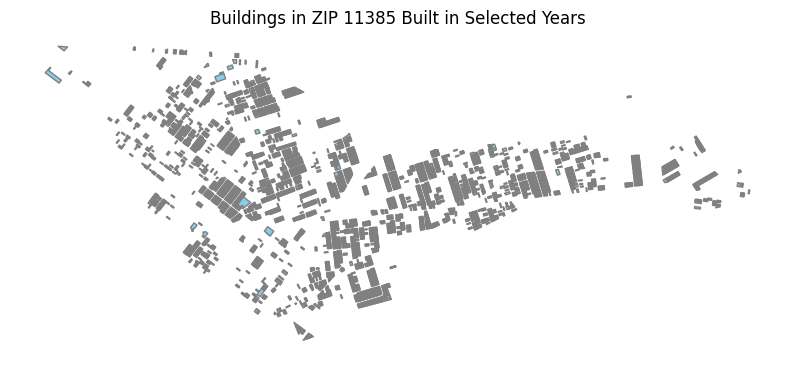

In [ ]:
target_years = [1914, 1909, 1910, 1924, 1925, 1926, 1911, 1913, 1915]
filtered = pluto[(pluto["ZipCode"] == 11385) & (pluto["YearBuilt"].isin(target_years))]

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
filtered.plot(ax=ax, color="skyblue", edgecolor="gray")
ax.set_title("Buildings in ZIP 11385 Built in Selected Years")
plt.axis("off")
plt.show()

In [24]:
print(filtered.crs)
filtered = filtered.to_crs(epsg=2263)

EPSG:4326


In [23]:
filtered.to_file("ridgewood_filtered.geojson", driver="GeoJSON")

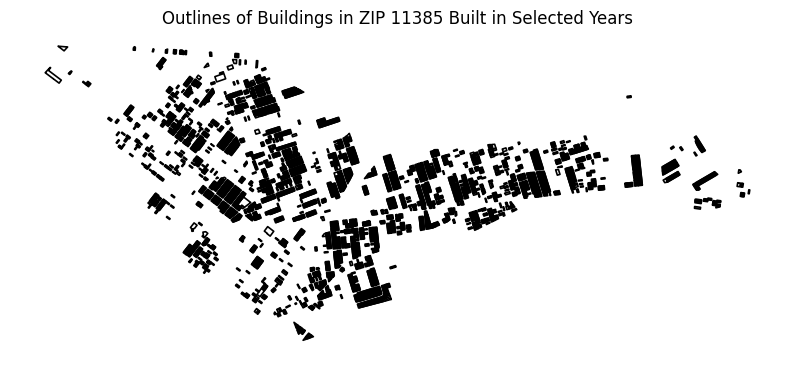

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot only outlines
filtered.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.2)

ax.set_title("Outlines of Buildings in ZIP 11385 Built in Selected Years")
ax.axis("off")

plt.show()

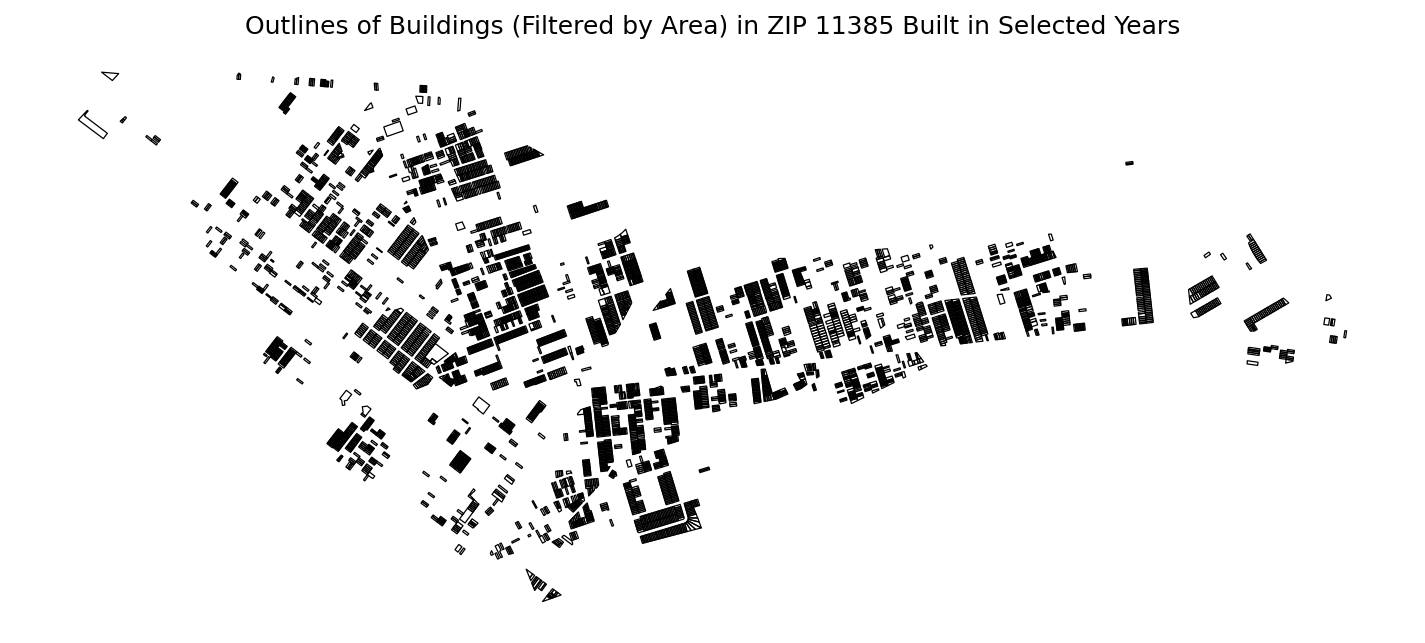

In [ ]:
import matplotlib.pyplot as plt

# Calculate polygon areas (in the current CRS units, likely feet or meters)
filtered["area"] = filtered.geometry.area

# Filter out very small buildings
area_threshold = 50
filtered_large = filtered[filtered["area"] > area_threshold]

fig, ax = plt.subplots(figsize=(12, 12), dpi=150)

# Plot only outlines, with thinner lines
filtered_large.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.6)

ax.set_title(
    "Outlines of Buildings (Filtered by Area) in ZIP 11385 Built in Selected Years"
)
ax.axis("off")

plt.show()

In [11]:
boundary = gpd.read_file("boundary.geojson")

In [ ]:
# Ensure the boundary CRS matches the filtered GeoDataFrame CRS
if boundary.crs != filtered.crs:
    boundary = boundary.to_crs(filtered.crs)

In [27]:
filtered_within_boundary = gpd.sjoin(
    filtered,
    boundary,
    how="inner",
    predicate="within",
)

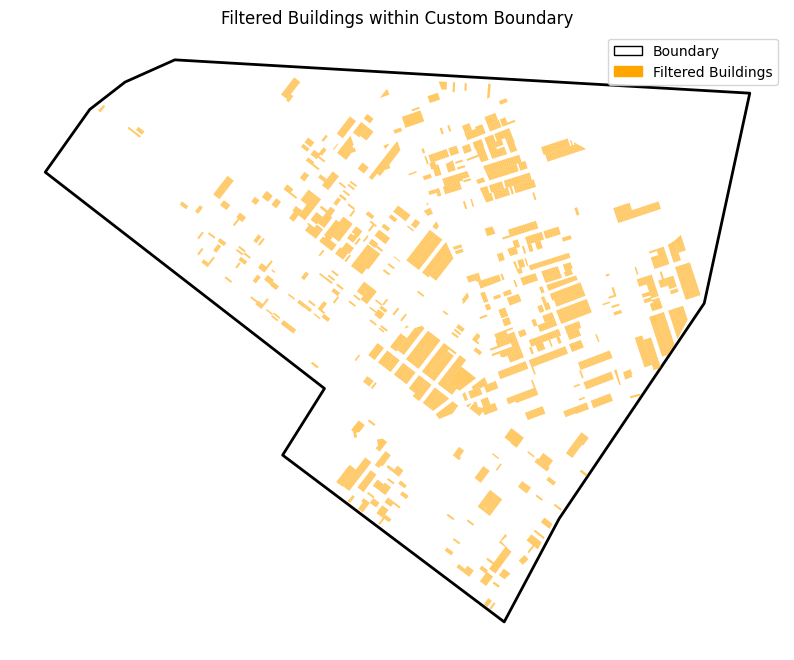

In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 10))

boundary.plot(ax=ax, color="none", edgecolor="black", linewidth=2)
filtered_within_boundary.plot(ax=ax, color="orange", alpha=0.6)

boundary_patch = mpatches.Patch(edgecolor="black", facecolor="none", label="Boundary")
filtered_patch = mpatches.Patch(color="orange", label="Filtered Buildings")
plt.legend(handles=[boundary_patch, filtered_patch])

plt.title("Filtered Buildings within Custom Boundary")
plt.axis("off")
plt.show()

In [44]:
filtered_within_boundary.to_file("filtered_within_boundary.geojson", driver="GeoJSON")

In [45]:
print(filtered_within_boundary.columns)
print(filtered_within_boundary["BuiltFAR"].head())

Index(['Borough', 'Block', 'Lot', 'CD', 'BCT2020', 'BCTCB2020', 'CT2010',
       'CB2010', 'SchoolDist', 'Council', 'ZipCode', 'FireComp', 'PolicePrct',
       'HealthCent', 'HealthArea', 'Sanitboro', 'SanitDistr', 'SanitSub',
       'Address', 'ZoneDist1', 'ZoneDist2', 'ZoneDist3', 'ZoneDist4',
       'Overlay1', 'Overlay2', 'SPDist1', 'SPDist2', 'SPDist3', 'LtdHeight',
       'SplitZone', 'BldgClass', 'LandUse', 'Easements', 'OwnerType',
       'OwnerName', 'LotArea', 'BldgArea', 'ComArea', 'ResArea', 'OfficeArea',
       'RetailArea', 'GarageArea', 'StrgeArea', 'FactryArea', 'OtherArea',
       'AreaSource', 'NumBldgs', 'NumFloors', 'UnitsRes', 'UnitsTotal',
       'LotFront', 'LotDepth', 'BldgFront', 'BldgDepth', 'Ext', 'ProxCode',
       'IrrLotCode', 'LotType', 'BsmtCode', 'AssessLand', 'AssessTot',
       'ExemptTot', 'YearBuilt', 'YearAlter1', 'YearAlter2', 'HistDist',
       'Landmark', 'BuiltFAR', 'ResidFAR', 'CommFAR', 'FacilFAR', 'BoroCode',
       'BBL', 'CondoNo', 'Tract2

In [46]:
print(filtered_within_boundary.geom_type.value_counts())

Polygon    2185
Name: count, dtype: int64


In [47]:
filtered_within_boundary = filtered_within_boundary.to_crs(epsg=4326)
filtered_within_boundary.to_file("filtered_within_boundary.geojson", driver="GeoJSON")

In [29]:
from shapely.geometry import LineString
import geopandas as gpd


def polygon_to_edges(polygon):
    coords = list(polygon.exterior.coords)
    edges = []
    for i in range(len(coords) - 1):
        edges.append(LineString([coords[i], coords[i + 1]]))
    return edges


edges_list = []

for idx, row in filtered_within_boundary.iterrows():
    edges = polygon_to_edges(row.geometry)
    props = row.drop(labels="geometry").to_dict()
    for edge in edges:
        edges_list.append({**props, "geometry": edge})

facade_gdf = gpd.GeoDataFrame(edges_list, crs=filtered_within_boundary.crs)

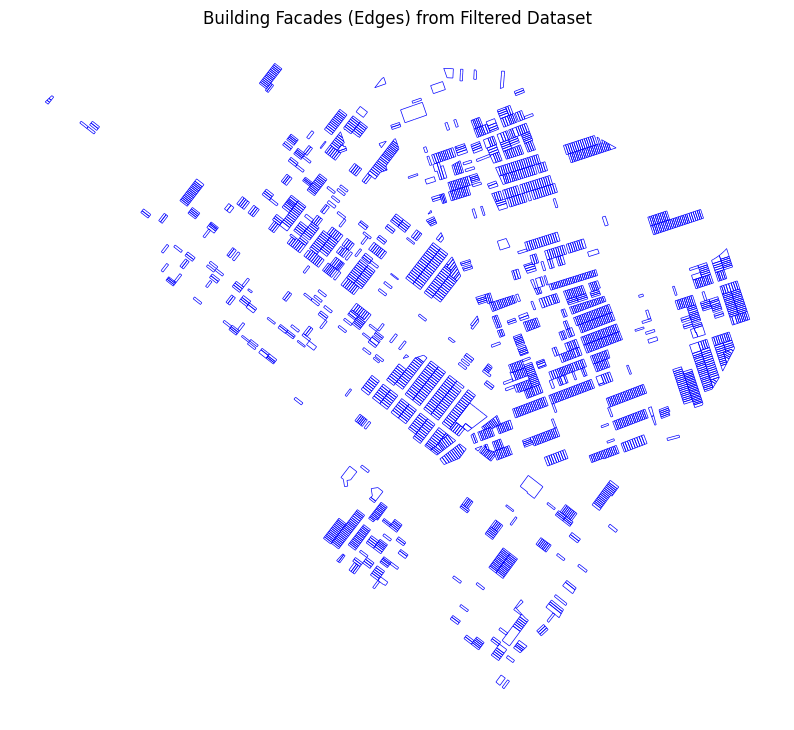

In [49]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
facade_gdf.plot(ax=ax, color="blue", linewidth=0.5)
plt.title("Building Facades (Edges) from Filtered Dataset")
plt.axis("off")
plt.show()

In [53]:
# Make sure all buildings are treated as one multipart geometry
dissolved = filtered_within_boundary.dissolve()

In [54]:
from shapely.geometry import LineString, MultiLineString

# Get only the exterior edges (as lines)
boundaries = dissolved.boundary

In [55]:
# Convert to GeoDataFrame
boundary_gdf = gpd.GeoDataFrame(
    geometry=boundaries.explode(index_parts=False), crs=filtered_within_boundary.crs
)

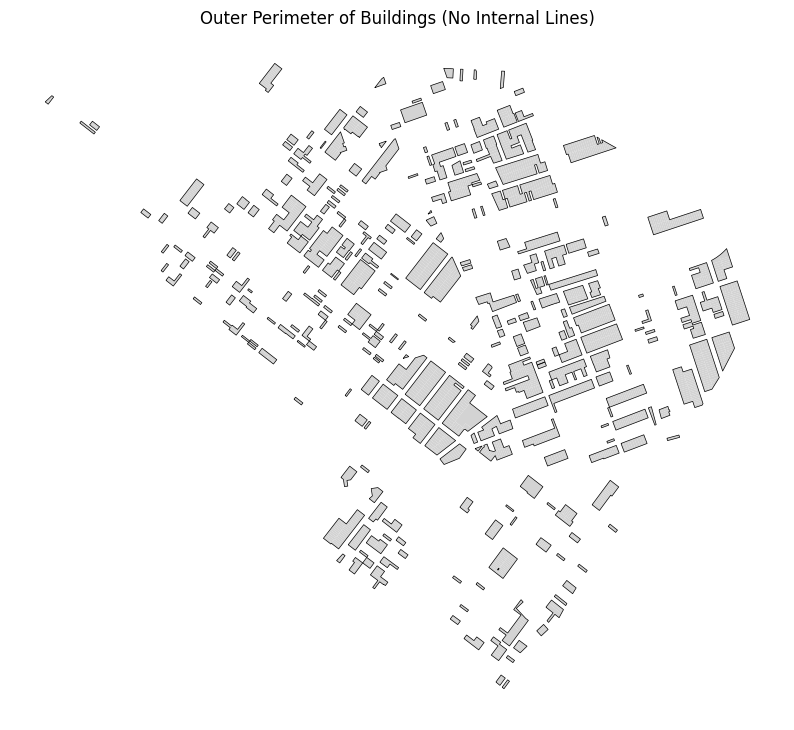

In [56]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
filtered_within_boundary.plot(ax=ax, facecolor="lightgray", edgecolor="none")
boundary_gdf.plot(ax=ax, color="black", linewidth=0.5)
plt.title("Outer Perimeter of Buildings (No Internal Lines)")
plt.axis("off")
plt.show()

Historical Context and Exploration

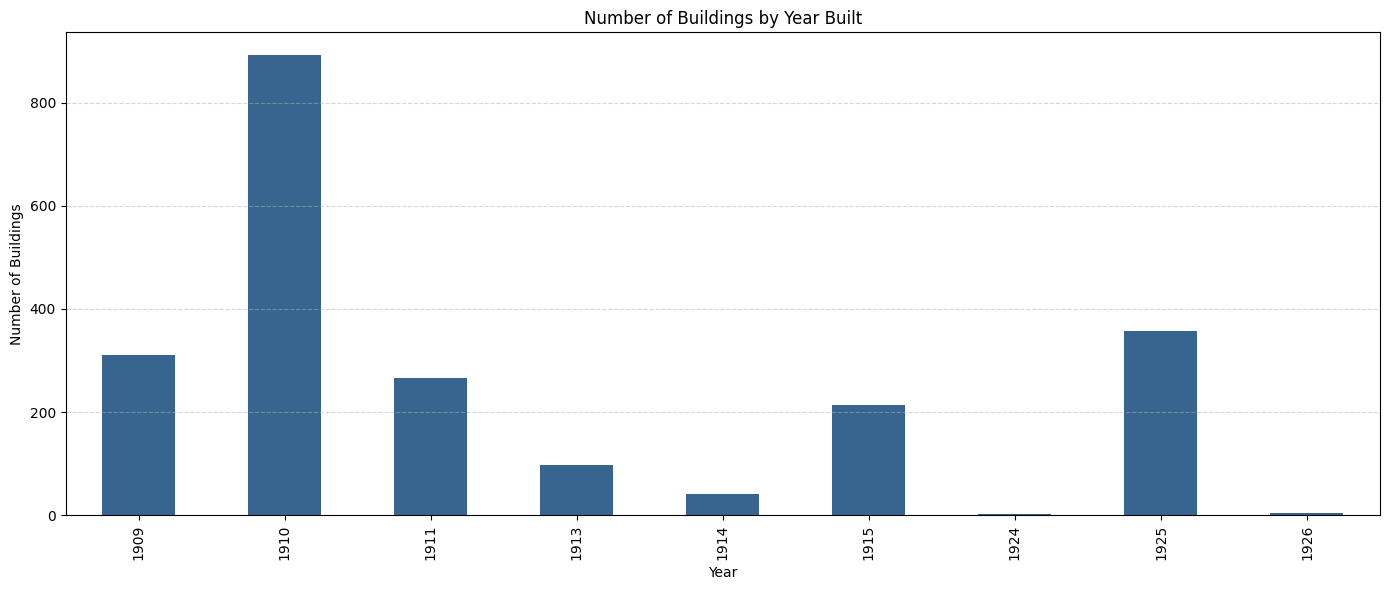

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load GeoJSON
gdf = gpd.read_file("filtered_within_boundary.geojson")

# Drop missing or invalid years
gdf = gdf[gdf["YearBuilt"].notnull()]
gdf = gdf[gdf["YearBuilt"] != 0]  # Exclude 0 if it's a placeholder

# Convert to integers
gdf["YearBuilt"] = gdf["YearBuilt"].astype(int)

# Filter reasonable range
gdf = gdf[(gdf["YearBuilt"] > 1800) & (gdf["YearBuilt"] < 2030)]

# Count buildings per year
year_counts = gdf["YearBuilt"].value_counts().sort_index()

# Plot
plt.figure(figsize=(14, 6))
year_counts.plot(kind="bar", color="#38658F")
plt.title("Number of Buildings by Year Built")
plt.xlabel("Year")
plt.ylabel("Number of Buildings")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

I'm also curious about the history of other buildings in the neighborhood, and wanted to explore what their years built are in contrast. 

In [14]:
import geopandas as gpd


# Ensure CRS matches
if pluto.crs != boundary.crs:
    pluto = pluto.to_crs(boundary.crs)

# Merge boundary polygons
boundary_union = boundary.unary_union

# Filter Pluto buildings that intersect with the boundary
pluto_in_boundary = pluto[pluto.geometry.intersects(boundary_union)]


# Drop invalid/missing YearBuilt
pluto_in_boundary = pluto_in_boundary[pluto_in_boundary["YearBuilt"].notnull()]
pluto_in_boundary = pluto_in_boundary[pluto_in_boundary["YearBuilt"] != 0]

# Convert to integer
pluto_in_boundary["YearBuilt"] = pluto_in_boundary["YearBuilt"].astype(int)

# Filter reasonable range
pluto_in_boundary = pluto_in_boundary[
    (pluto_in_boundary["YearBuilt"] > 1800) & (pluto_in_boundary["YearBuilt"] < 2030)
]

# Years already accounted for
years_to_exclude = {1914, 1909, 1910, 1924, 1925, 1926, 1911, 1913, 1915}

# Filter out those years
remaining_buildings = pluto_in_boundary[
    ~pluto_in_boundary["YearBuilt"].isin(years_to_exclude)
]

# (Optional) Save result
remaining_buildings.to_file("remaining_buildings.geojson", driver="GeoJSON")

print(f"Total buildings in boundary: {len(pluto_in_boundary)}")
print(f"Remaining after exclusion: {len(remaining_buildings)}")

/var/folders/w9/wqjyy9552z99wh2hxtn_2nbw0000gn/T/ipykernel_43789/1039321723.py:9: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  boundary_union = boundary.unary_union


Total buildings in boundary: 7683
Remaining after exclusion: 5403


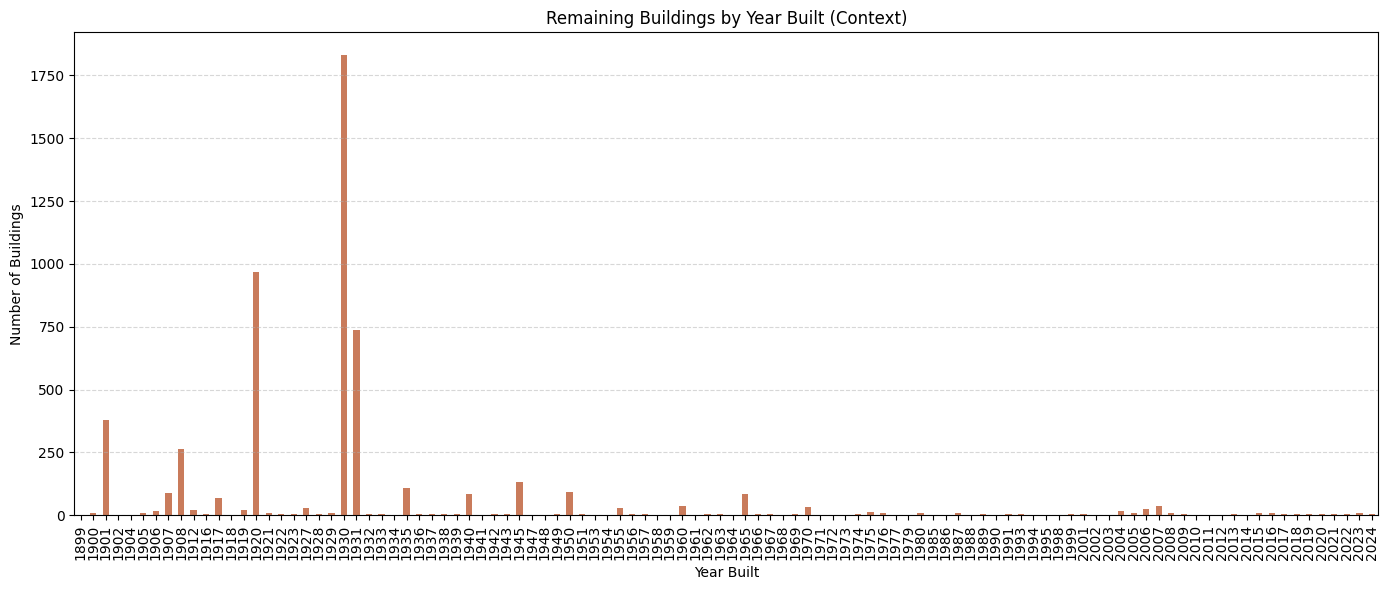

In [11]:
import matplotlib.pyplot as plt

# Count remaining buildings per year
year_counts_remaining = remaining_buildings["YearBuilt"].value_counts().sort_index()

# Plot
plt.figure(figsize=(14, 6))
year_counts_remaining.plot(kind="bar", color="#C97B5B")
plt.title("Remaining Buildings by Year Built (Context)")
plt.xlabel("Year Built")
plt.ylabel("Number of Buildings")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

These results are really interesting and I'm super curious what caused this massive spike in 1930-31 and 1920. 
Finally I wanted to better contextualize the years built I am using in my main dataset. 

<Figure size 1400x600 with 0 Axes>

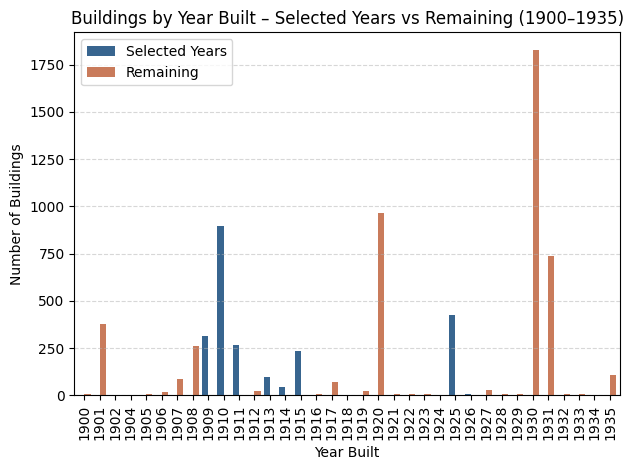

In [19]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt


# --- Ensure matching CRS ---
if pluto.crs != boundary.crs:
    pluto = pluto.to_crs(boundary.crs)

# --- Keep only polygon geometries in boundary ---
boundary = boundary[boundary.geometry.type.isin(["Polygon", "MultiPolygon"])]

# --- Merge boundary polygons into one ---
boundary = boundary.dissolve()

# --- Clip Pluto buildings to neighborhood ---
pluto_in_boundary = gpd.overlay(pluto, boundary, how="intersection")

# --- Clean YearBuilt ---
pluto_in_boundary = pluto_in_boundary[pluto_in_boundary["YearBuilt"].notnull()]
pluto_in_boundary = pluto_in_boundary[pluto_in_boundary["YearBuilt"] != 0]
pluto_in_boundary["YearBuilt"] = pluto_in_boundary["YearBuilt"].astype(int)
pluto_in_boundary = pluto_in_boundary[
    (pluto_in_boundary["YearBuilt"] > 1800) & (pluto_in_boundary["YearBuilt"] < 2030)
]

# --- Define your years of interest ---
years_interest = {1914, 1909, 1910, 1924, 1925, 1926, 1911, 1913, 1915}

# --- Split into two groups ---
selected_buildings = pluto_in_boundary[
    pluto_in_boundary["YearBuilt"].isin(years_interest)
]
remaining_buildings = pluto_in_boundary[
    ~pluto_in_boundary["YearBuilt"].isin(years_interest)
]

# --- Count by year ---
counts_interest = selected_buildings["YearBuilt"].value_counts().sort_index()
counts_remaining = remaining_buildings["YearBuilt"].value_counts().sort_index()

# --- Merge counts into one DataFrame ---
df_counts = pd.DataFrame(
    {"Selected Years": counts_interest, "Remaining": counts_remaining}
).fillna(0)

# --- Keep only years with buildings in at least one category ---
df_counts = df_counts[(df_counts["Selected Years"] > 0) | (df_counts["Remaining"] > 0)]

# --- Limit to 1900–1935 ---
df_counts = df_counts[(df_counts.index >= 1900) & (df_counts.index <= 1935)]

# --- Plot ---
plt.figure(figsize=(14, 6))
df_counts.plot(kind="bar", color=["#38658F", "#C97B5B"], width=0.8)
plt.title("Buildings by Year Built – Selected Years vs Remaining (1900–1935)")
plt.xlabel("Year Built")
plt.ylabel("Number of Buildings")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()